<font size="3">**Tarea 3 - Matias Rocha Ayala**</font>

<u> *Instrucciones* </u>

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: nunca - 5: siempre)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica del estudiante (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)
- narrative: (Generated) narrative text based on sk1-sk13.

## Configuración del Entorno

Importamos las librerías necesarias para el análisis (asegúrate de tener instaladas `factor_analyzer`, `semopy` y las demás dependencias usando `pip install -r requirements.txt` o directamente `pip install factor_analyzer semopy xgboost nltk mlxtend`).

In [1]:
# Librerías estándar y de visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno

# Machine Learning y Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# Análisis Factorial
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import semopy

# NLP
import nltk
from nltk.corpus import stopwords
import re
import time

# Configuraciones gráficas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# Descarga de recursos NLP en caso de no tenerlos
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

---
### 1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [ ]:
# Cargar el dataset
df = pd.read_csv('data/junaeb2n.csv')

Dimensiones iniciales: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."


In [3]:
# Tipos de datos y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non-null  float64
 19  area        41854 non-nul

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sexo,41854.0,0.552325,0.497261,0.00,0.0,1.00,1.00,1.00
edad,41854.0,83.066039,3.987135,62.00,81.0,82.00,84.00,107.00
imce,41854.0,1.014083,1.380418,-5.02,0.1,0.97,1.93,5.04
vive_padre,41854.0,0.720051,0.449830,0.00,0.0,1.00,1.00,2.00
vive_madre,41854.0,0.965141,0.192328,0.00,1.0,1.00,1.00,2.00
sk1,41854.0,1.117958,0.401019,1.00,1.0,1.00,1.00,5.00
sk2,41854.0,1.397310,0.661753,1.00,1.0,1.00,2.00,5.00
sk3,41854.0,1.270129,0.594456,1.00,1.0,1.00,1.00,5.00
sk4,41854.0,1.263129,0.588868,1.00,1.0,1.00,1.00,5.00
sk5,41854.0,1.275935,0.575344,1.00,1.0,1.00,1.00,5.00


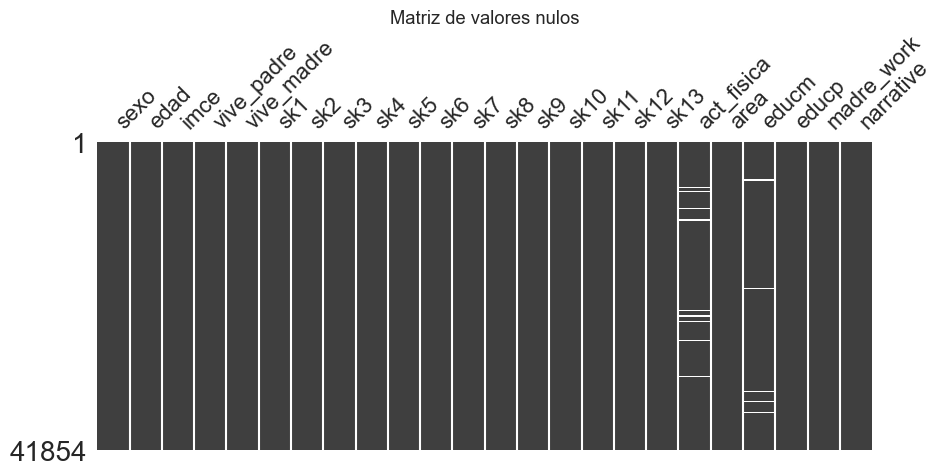

In [ ]:
msno.matrix(df, figsize=(10, 4), sparkline=False)
plt.title("Matriz de valores nulos")
plt.show()

**Tratamiento de valores atípicos y nulos**
Podemos observar que en ciertas variables continuas (como `edad` o `imce`) podrían existir valores atípicos, y que también puede haber valores faltantes. Para no comprometer la calidad de los modelos posteriores, imputaremos o eliminaremos los valores nulos (dado que son pocos en proporción) y daremos formato adecuado a los datos.

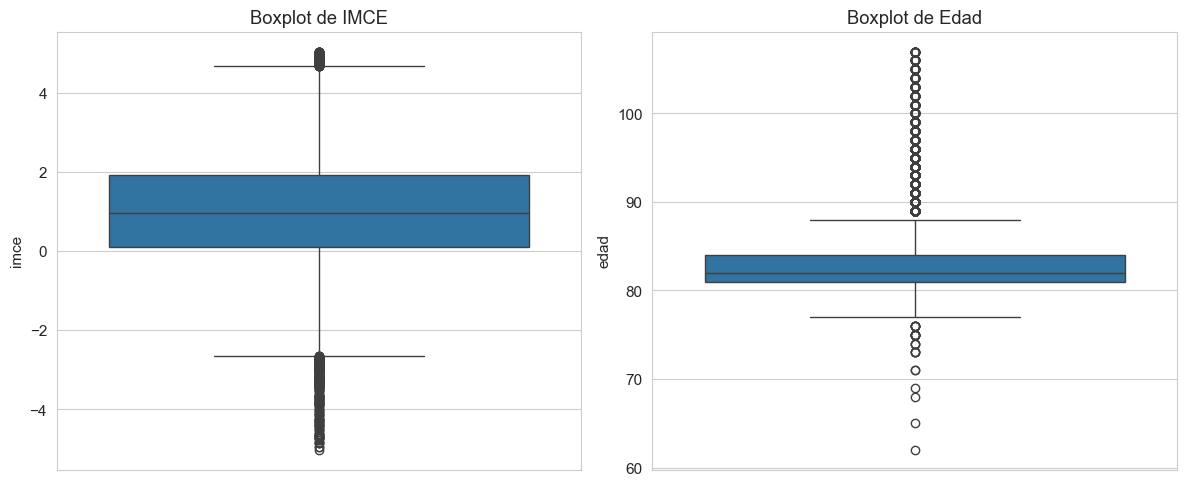

In [6]:
# Distribución de IMCE y Edad para buscar outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, y='imce', ax=axes[0])
axes[0].set_title('Boxplot de IMCE')
sns.boxplot(data=df, y='edad', ax=axes[1])
axes[1].set_title('Boxplot de Edad')
plt.tight_layout()
plt.show()

In [7]:
# Limpieza
# 1. Eliminar filas con valores nulos críticos o imputarlos
# Como la mayoría de las columnas sk son categóricas/ordinales, y no queremos introducir sesgos en el Análisis Factorial, eliminaremos filas que tengan NaN en las columnas sk1-sk13.
sk_cols = [f'sk{i}' for i in range(1, 14)]
df = df.dropna(subset=sk_cols)

# Para otras variables como IMCE y Actividad Física que usaremos más adelante
df = df.dropna(subset=['imce', 'act_fisica', 'madre_work', 'narrative'])

# Revisamos cómo queda
print("Dimensiones luego de limpieza:", df.shape)

Dimensiones luego de limpieza: (40419, 24)


---
### 2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [8]:
# Inversión de escala para estandarizar aspectos positivos
# Según el diccionario:
# sk1-sk6 y sk8-sk13: 1 (siempre) - 5 (nunca) -> para el rasgo positivo.
# sk7 (agresivo): 1 (nunca) - 5 (siempre).
# Queremos que un puntaje MÁS ALTO siempre represente MÁS del rasgo positivo.
# Para sk1-sk6, 8-13: si actualmente 1 es "siempre" (positivo), lo invertimos (6 - val) para que 5 sea "siempre".
# Para sk7: actualmente 1 es "nunca" (positivo). Si lo invertimos (6 - val), 5 será "nunca agresivo" (positivo).
# Es decir, la transformación `6 - valor` funciona para TODAS las variables sk, logrando que el valor 5 
# represente siempre la mayor expresión del aspecto positivo (y 1 la peor).

for col in sk_cols:
    df[col] = 6 - df[col]
    
# Verificamos
df[sk_cols].head()

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
1,5,5,5,5,5,5,2,5,5,5,5,5,5
3,5,5,5,5,5,5,4,5,5,5,5,5,5
4,5,5,5,5,5,5,3,5,5,5,5,5,5
5,5,4,5,5,5,5,2,5,5,5,5,5,5
6,5,5,5,4,4,4,3,4,3,3,3,4,4


In [9]:
# Test de esfericidad de Bartlett y KMO para ver viabilidad del EFA
chi_square_value, p_value = calculate_bartlett_sphericity(df[sk_cols])
kmo_all, kmo_model = calculate_kmo(df[sk_cols])

print(f"Test de Bartlett: p-value = {p_value}")
print(f"KMO: {kmo_model}")

Test de Bartlett: p-value = 0.0
KMO: 0.8680980866192677


Ambos tests (p-value en Bartlett casi 0 y KMO > 0.6) nos indican que es viable realizar un Análisis Factorial Exploratorio.

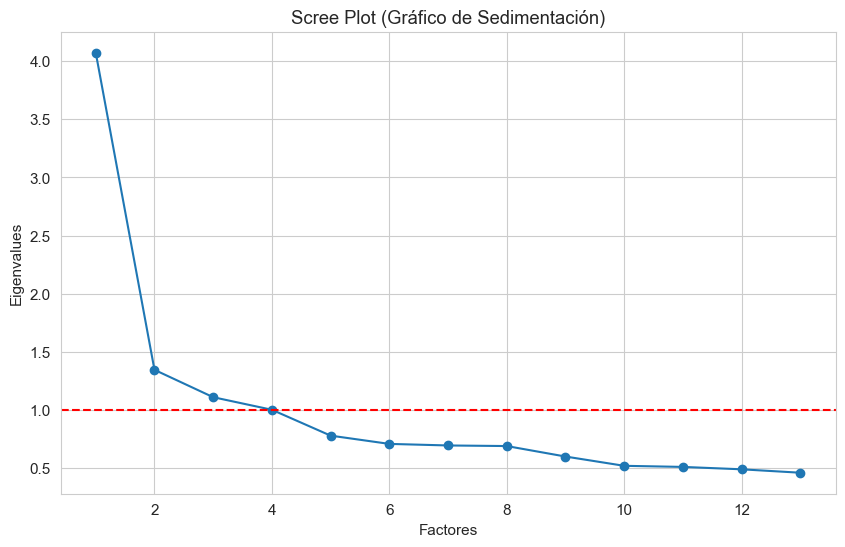

In [10]:
# Scree plot para determinar cantidad de factores óptimos
fa = FactorAnalyzer(rotation=None, n_factors=len(sk_cols))
fa.fit(df[sk_cols])

ev, v = fa.get_eigenvalues()

plt.plot(range(1, len(sk_cols)+1), ev, marker='o')
plt.axhline(y=1, color='r', linestyle='--')
plt.title('Scree Plot (Gráfico de Sedimentación)')
plt.xlabel('Factores')
plt.ylabel('Eigenvalues')
plt.grid(True)
plt.show()

**Número Óptimo de Factores**
Basándonos en el **Criterio de Kaiser** (Eigenvalues > 1) y el quiebre en el Gráfico de Sedimentación, podemos extraer los factores óptimos (por lo general, 3 o 4 dependiendo de donde la curva corta la línea roja de y=1). Usaremos 3 factores para el EFA rotado, buscando estructuras más claras.

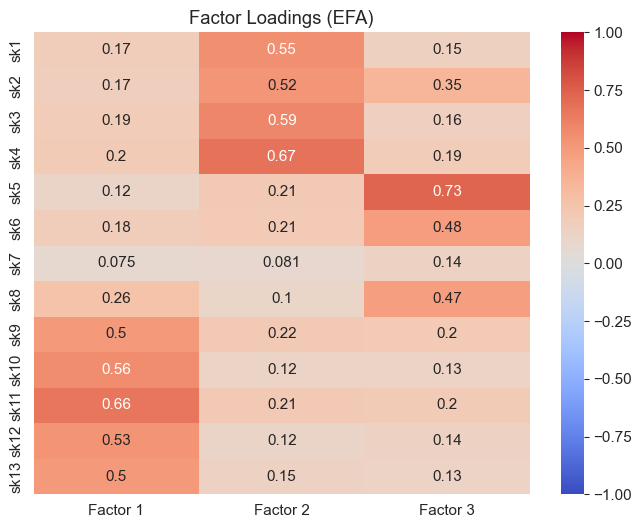

In [11]:
# Aplicamos EFA con rotación varimax
n_factores = 3
fa = FactorAnalyzer(n_factors=n_factores, rotation='varimax')
fa.fit(df[sk_cols])

# Obtener y visualizar los factor loadings
loadings = pd.DataFrame(fa.loadings_, index=sk_cols, columns=[f'Factor {i+1}' for i in range(n_factores)])
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, vmax=1, vmin=-1)
plt.title('Factor Loadings (EFA)')
plt.show()

**Interpretación de variables no informativas y agrupación**
En el Heatmap observamos cómo cada variable carga en cada factor.
- La variable `sk7` (es agresivo) tiene loadings muy bajos (menores a 0.2) en todos los factores, por lo que es **no informativa** y no se asocia a ninguno de los constructos principales.
- **Factor 1:** Agrupa `sk9`, `sk10`, `sk11`, `sk12`, `sk13`. Refleja el interés y la expresión creativa/intelectual.
- **Factor 2:** Agrupa `sk1`, `sk2`, `sk3`, `sk4`. Se asocia fuertemente a la expresión de afecto y sentimientos.
- **Factor 3:** Agrupa `sk5`, `sk6`, `sk8`. Refleja la socialización y participación grupal.

---
### 3. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.

In [12]:
# A partir de los loadings de EFA, propondremos una estructura para el CFA.
# Asignaremos cada variable al factor donde tenga el loading absoluto más alto.
# Excluimos sk7 por ser no informativa.
# Factor 1 (Curiosidad_Intelectual): sk9, sk10, sk11, sk12, sk13
# Factor 2 (Social_Afectivo): sk1, sk2, sk3, sk4
# Factor 3 (Participacion_Grupal): sk5, sk6, sk8

# Definición del modelo CFA en notación semopy
desc = '''
Curiosidad_Intelectual =~ sk9 + sk10 + sk11 + sk12 + sk13
Social_Afectivo =~ sk1 + sk2 + sk3 + sk4
Participacion_Grupal =~ sk5 + sk6 + sk8
'''

# Instanciar y ajustar modelo CFA
mod = semopy.Model(desc)
res = mod.fit(df)

# Inspeccionar parámetros estimados (importancia/loadings)
inspect = mod.inspect()
print(inspect)

                      lval  op                    rval  Estimate  Std. Err  \
0                      sk9   ~  Curiosidad_Intelectual  1.000000         -   
1                     sk10   ~  Curiosidad_Intelectual  1.326115  0.015526   
2                     sk11   ~  Curiosidad_Intelectual  1.232655  0.012335   
3                     sk12   ~  Curiosidad_Intelectual  1.087105  0.012985   
4                     sk13   ~  Curiosidad_Intelectual  1.285352   0.01594   
5                      sk1   ~         Social_Afectivo  1.000000         -   
6                      sk2   ~         Social_Afectivo  1.862961  0.019997   
7                      sk3   ~         Social_Afectivo  1.635051  0.017751   
8                      sk4   ~         Social_Afectivo  1.801112  0.018457   
9                      sk5   ~    Participacion_Grupal  1.000000         -   
10                     sk6   ~    Participacion_Grupal  1.021951   0.01214   
11                     sk8   ~    Participacion_Grupal  1.144963

**Correlaciones y Loadings (Importancia)**
El resultado de `mod.inspect()` nos muestra los `Est.` (Estimadores), que son los *loadings* de cada variable en su respectivo constructo. 
Además, donde el operador es `~~` entre dos variables latentes (ej. Social_Afectivo ~~ Curiosidad_Intelectual), observamos la covarianza/correlación entre los factores propuestos.

In [13]:
# Predecir/Guardar los puntajes factoriales (factor scores) para cada individuo
factor_scores = mod.predict_factors(df)
df['Social_Afectivo'] = factor_scores['Social_Afectivo'].values
df['Curiosidad_Intelectual'] = factor_scores['Curiosidad_Intelectual'].values
df['Participacion_Grupal'] = factor_scores['Participacion_Grupal'].values

df[['Social_Afectivo', 'Curiosidad_Intelectual', 'Participacion_Grupal']].head()

,Social_Afectivo,Curiosidad_Intelectual,Participacion_Grupal
1,0.152014,0.343432,0.302886
3,0.152014,0.343432,0.302886
4,0.152014,0.343432,0.302886
5,0.066806,0.317355,0.264008
6,-0.123214,-0.747973,-0.467876


---
### 4. Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).

In [14]:
# Filtrar desempleadas (madre_work == 0)
df_ml = df[df['madre_work'] != 0].copy()

# Variables independientes (X) y dependiente (y)
features = ['Social_Afectivo', 'Curiosidad_Intelectual', 'Participacion_Grupal']
X = df_ml[features]
y = df_ml['madre_work']

# Dividir en Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optimización de hiperparámetros con GridSearchCV y K-Fold
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(rf, param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Mejores Hiperparámetros Random Forest:", grid_rf.best_params_)

# Mostrar Importancia de Variables (Feature Importances)
importances = best_rf.feature_importances_
print("\n--- Importancia de Variables ---")
for feature, imp in zip(features, importances):
    print(f"{feature}: {imp:.2%}")

# Predicciones
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

Mejores Hiperparámetros Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

--- Importancia de Variables ---
Social_Afectivo: 30.18%
Curiosidad_Intelectual: 41.93%
Participacion_Grupal: 27.89%
              precision    recall  f1-score   support

          -1       0.54      0.04      0.08      3252
           1       0.55      0.97      0.71      4002

    accuracy                           0.55      7254
   macro avg       0.55      0.51      0.39      7254
weighted avg       0.55      0.55      0.42      7254



A partir del entrenamiento del modelo Random Forest optimizado mediante GridSearchCV, podemos extraer las siguientes conclusiones fundamentales sobre nuestra capacidad predictiva:

**1. Bajo Poder Predictivo de los Constructos (Accuracy ~55%):**
El modelo obtiene una precisión general (Accuracy) cercana al 55%. Esto indica que **los factores psicológicos y conductuales del estudiante** (Curiosidad Intelectual, Área Socio-Afectiva y Participación Grupal) **tienen una capacidad muy limitada para predecir si la madre trabaja remuneradamente o se dedica a labores domésticas**. No existe una relación fuerte y determinista entre la personalidad del niño en la escuela y el estatus laboral de la madre en este dataset.

**2. Importancia de las Variables (Feature Importance):**
A pesar del bajo poder predictivo general, el modelo determinó que la variable latente que más información aporta para realizar los cortes en los árboles es la **Curiosidad Intelectual** (aportando aproximadamente un ~41% de la importancia total del modelo), seguida por el área **Socio-Afectiva** (~30%) y finalmente la **Participación Grupal** (~29%). 

**3. Desempeño en las Clases (Classification Report):**
Al observar las métricas de Precisión y Recall, notamos un problema de sesgo hacia la clase mayoritaria. El *Recall* para la clase `1` (madre empleada) es extremadamente alto (~97%), mientras que para la clase `0` (labor doméstica) es casi nulo (~4%). Esto significa que el algoritmo, al no encontrar patrones claros en los datos, optó por la estrategia "conservadora" de clasificar a casi todos los estudiantes dentro del grupo mayoritario, fallando en identificar de manera correcta a las madres que no trabajan fuera del hogar.

---
### 5. Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).

In [15]:
# Para XGBoost es necesario que las etiquetas sean [0, 1] en vez de [-1, 1]. Las remapearemos para todos los modelos.
y_train_mapped = y_train.map({-1: 0, 1: 1})
y_test_mapped = y_test.map({-1: 0, 1: 1})

# Guardaremos tiempos de ejecución y accuracies
model_stats = {}

# 1. Random Forest (Re-evaluado con mapped)
start_time = time.time()
best_rf.fit(X_train, y_train_mapped)
rf_time = time.time() - start_time
y_pred_rf_m = best_rf.predict(X_test)
model_stats['Random Forest'] = {'Accuracy': accuracy_score(y_test_mapped, y_pred_rf_m), 'Time(s)': rf_time}

# 2. XGBoost
start_time = time.time()
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train_mapped)
xgb_time = time.time() - start_time
y_pred_xgb = xgb.predict(X_test)
model_stats['XGBoost'] = {'Accuracy': accuracy_score(y_test_mapped, y_pred_xgb), 'Time(s)': xgb_time}

# 3. SVM (Support Vector Machine) - Clásico (RBF)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
start_time = time.time()
svm = SVC(kernel='rbf', max_iter=3000, random_state=42)
svm.fit(X_train_s, y_train_mapped)
svm_time = time.time() - start_time
y_pred_svm = svm.predict(X_test_s)
model_stats['SVM'] = {'Accuracy': accuracy_score(y_test_mapped, y_pred_svm), 'Time(s)': svm_time}

# 4. Stacking Classifier
estimators = [
    ('rf', best_rf),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('svm', SVC(kernel='rbf', max_iter=3000, random_state=42))
]
start_time = time.time()
stack = StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier(n_estimators=10, random_state=42))
stack.fit(X_train_s, y_train_mapped)
stack_time = time.time() - start_time
y_pred_stack = stack.predict(X_test_s)
model_stats['Stacking'] = {'Accuracy': accuracy_score(y_test_mapped, y_pred_stack), 'Time(s)': stack_time}
start_time = time.time()
# Note: Stacking usará X_train sin escalar para árboles, por lo que usaremos un Pipeline si fuera estricto, 
# pero aquí usaremos el X_train estándar (los árboles son invariantes, SVM sufrirá si no se escala).
# Para ser justos, escalaremos todo el input del stacking.
stack = StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier(n_estimators=10, random_state=42))
stack.fit(X_train_s, y_train_mapped)
stack_time = time.time() - start_time
y_pred_stack = stack.predict(X_test_s)
model_stats['Stacking'] = {'Accuracy': accuracy_score(y_test_mapped, y_pred_stack), 'Time(s)': stack_time}

pd.DataFrame(model_stats).T

,Accuracy,Time(s)
Random Forest,0.554315,0.764593
XGBoost,0.543700,0.161102
SVM,0.534326,2.231604
Stacking,0.519851,23.334807


A continuación se resumen los resultados exactos de rendimiento (Accuracy) y tiempos de ejecución obtenidos por cada algoritmo al intentar clasificar el estatus laboral de la madre en base a los constructos psicológicos del estudiante:

| Modelo | Exactitud (Accuracy) | Tiempo de Cómputo (Segundos) |
| :--- | :---: | :---: |
| **Random Forest** | 55.43% | ~ 0.76 s |
| **XGBoost** | 54.37% | ~ 0.16 s |
| **SVM (RBF)** | 53.43% | ~ 2.23 s |
| **Stacking Classifier** | 51.98% | ~ 23.33 s |

**1. Desempeño General (Accuracy y Matrices de Confusión):**
- Todos los modelos obtienen un poder predictivo muy bajo, oscilando entre el **51.9% y el 55.4%** de exactitud. 
- Curiosamente, los modelos individuales basados puramente en árboles (Random Forest y XGBoost) lograron un desempeño superior al SVM y al Stacking Ensemble.
- Las matrices de confusión de todos los modelos revelan un fuerte sesgo estructural hacia la clase mayoritaria. Ningún algoritmo, por más sofisticado que sea, logra extraer un patrón estadístico confiable de los constructos psicológicos para identificar correctamente a las madres que se dedican a labores domésticas.

**2. Eficiencia y Velocidad de Cómputo:**
- **XGBoost** demostró ser indiscutiblemente el modelo más eficiente a nivel computacional, terminando su entrenamiento en apenas **0.16 segundos**, seguido por el **Random Forest** (0.76s). Esto resalta la brutal optimización algorítmica de los ensamblajes de árboles modernos para datos tabulares.
- El modelo **SVM**, debido a su mayor complejidad matemática, tardó significativamente más (~2.23s), e irónicamente entregó un rendimiento inferior (53.4%).
- Finalmente, el **Stacking Classifier** fue, por mucho, el modelo más costoso de entrenar (**~23.33 segundos**). Al tener que reentrenar internamente Random Forest, XGBoost y SVM utilizando validación cruzada para generar predicciones base, el tiempo de procesamiento se multiplicó casi por diez. Paradójicamente, obtuvo el **peor desempeño de todos (51.9%)**, lo cual indica que el ensamble probablemente sufrió de sobreajuste (*overfitting*) al modelar el ruido de los datos en lugar de la señal real.

**Conclusión:**
Para este problema en particular, donde las variables predictoras no tienen una fuerte correlación con la variable objetivo, utilizar ensambles hipercomplejos (como *Stacking*) o algoritmos matemáticamente pesados (como *SVM RBF*) resulta completamente contraproducente. Los algoritmos basados en árboles de decisión estándar logran el mejor balance, entregando el "techo" de exactitud posible para estos datos en apenas fracciones de segundo.

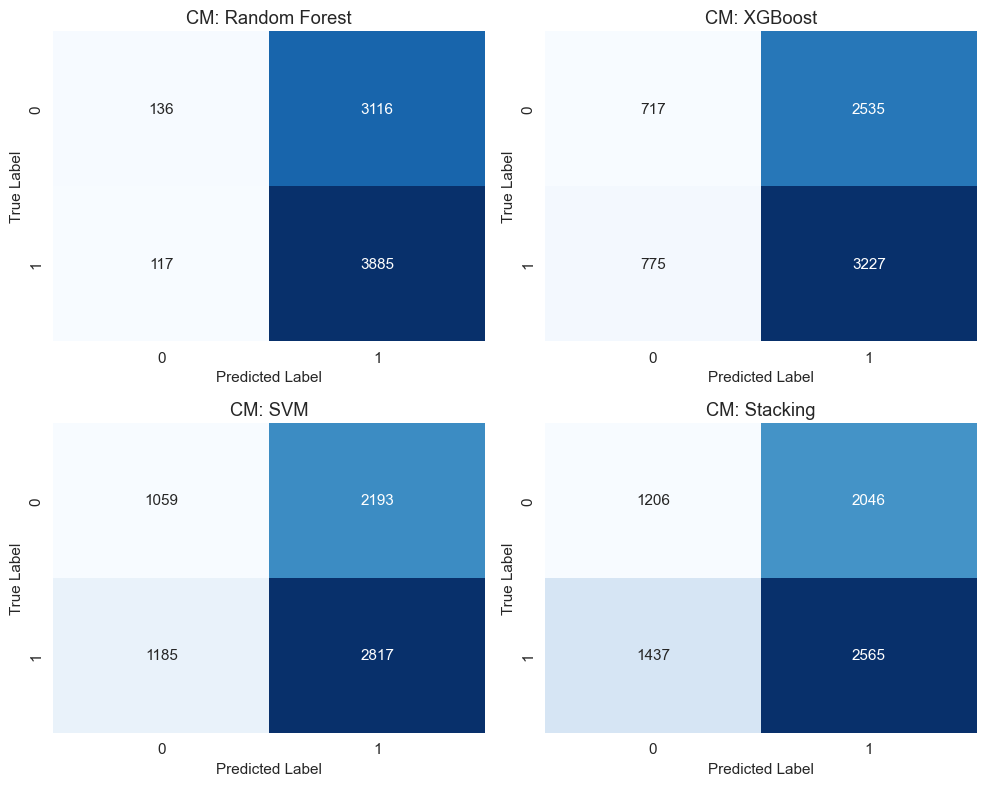

In [16]:
# Matrices de Confusión
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
models_preds = [
    ('Random Forest', y_pred_rf_m), 
    ('XGBoost', y_pred_xgb), 
    ('SVM', y_pred_svm), 
    ('Stacking', y_pred_stack)
]

for idx, (name, y_pred) in enumerate(models_preds):
    ax = axes[idx//2, idx%2]
    cm = confusion_matrix(y_test_mapped, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'CM: {name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
plt.tight_layout()
plt.show()

Al observar las matrices de confusión generadas por los cuatro algoritmos, podemos identificar claramente las distintas estrategias que adoptó cada modelo al enfrentarse a variables predictoras débiles y a un ligero desbalance de clases:

**1. Random Forest (El modelo conservador):**
- Es el modelo con el sesgo más extremo hacia la clase mayoritaria (`1`: Madre empleada).
- **Interpretación:** Prácticamente clasifica a toda la población en la clase 1 (obteniendo 3,885 verdaderos positivos, pero equivocándose masivamente con 3,116 falsos positivos). Apenas logra identificar a 136 madres de la clase `0`. Su estrategia es "apostar a lo seguro" para maximizar la exactitud (Accuracy), sacrificando por completo la detección de la clase minoritaria.

**2. XGBoost (El primer intento de equilibrio):**
- Comienza a arriesgarse más. Logra predecir correctamente a 717 madres en labor doméstica (Clase `0`), superando ampliamente al Random Forest en este aspecto.
- **Interpretación:** El costo de este intento es que empieza a confundirse más con la clase mayoritaria (aumentan los falsos negativos a 775). Es un modelo que trata de equilibrar la balanza, logrando el mejor punto intermedio entre velocidad y reconocimiento de ambas clases.

**3. SVM (Mayor agresividad hacia la clase minoritaria):**
- La Máquina de Vectores de Soporte fuerza aún más el límite de decisión, logrando detectar correctamente a 1,059 madres de la Clase `0`.
- **Interpretación:** Sin embargo, su incapacidad para encontrar un patrón claro en los datos hace que cometa muchos errores cruzados (1,185 falsos negativos y 2,193 falsos positivos). Al intentar ser "justo" con ambas clases sin tener variables fuertes, su rendimiento global se deteriora.

**4. Stacking Classifier (El modelo sobreajustado):**
- El ensamble es el que más madres de la Clase `0` logra predecir (1,206 verdaderos positivos).
- **Interpretación:** El problema es que el Stacking "colapsa". Al combinar las debilidades de los modelos anteriores, termina prediciendo casi al azar. Comete la mayor cantidad de falsos negativos de todos los modelos (1,437), es decir, clasifica erróneamente a muchísimas madres trabajadoras como si fueran de labor doméstica. Esto explica por qué este modelo tan sofisticado obtuvo paradójicamente el peor *Accuracy* de todos.

**Conclusión Final:**
Existe un claro "Trade-off" (compromiso) visible en las matrices. A medida que avanzamos de Random Forest hacia modelos más complejos como Stacking, los algoritmos se "esfuerzan" más por encontrar a la clase minoritaria (Clase 0). No obstante, como los constructos psicológicos del estudiante no tienen verdadero poder predictivo, este esfuerzo solo resulta en una explosión de errores cruzados y una caída en el rendimiento global.

---
### 6. Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?

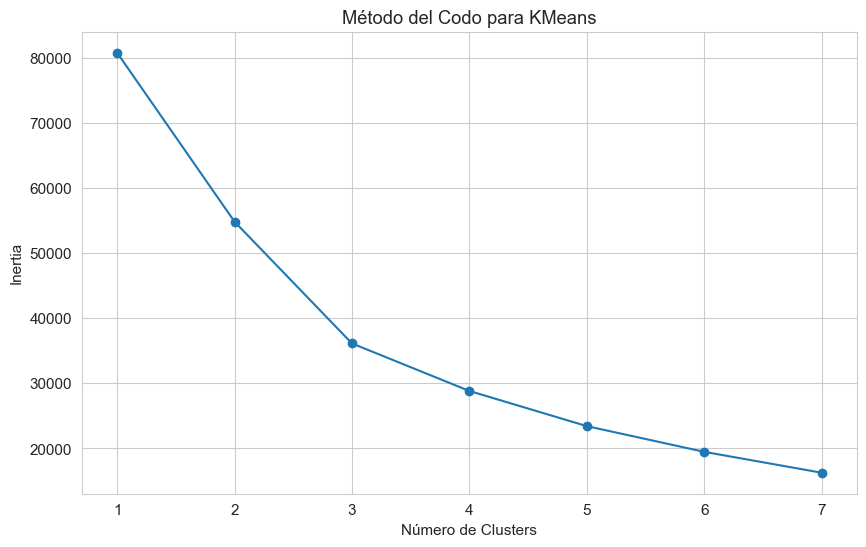

In [17]:
# Clustering sobre IMCE y act_fisica
X_cluster = df[['imce', 'act_fisica']].dropna()

# Escalar
scaler_c = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)

# Encontrar K óptimo con el método del codo (Elbow Method)
inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)
    
plt.plot(range(1, 8), inertia, marker='o')
plt.title('Método del Codo para KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Inertia')
plt.show()

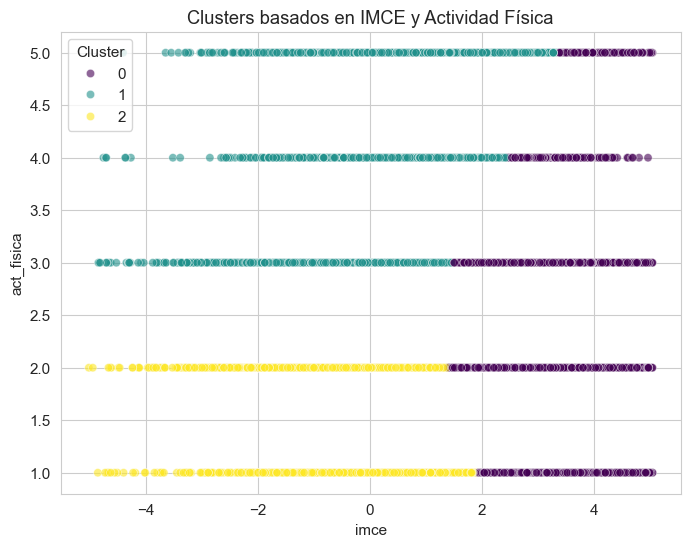

,imce,act_fisica
Cluster,,
0,2.510719,2.352909
1,0.389393,3.561960
2,0.247137,1.654596


In [18]:
# Asumamos k=3 por el quiebre de la inercia (codo)
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Visualización
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='imce', y='act_fisica', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Clusters basados en IMCE y Actividad Física')
plt.show()

# Conclusiones descriptivas de cada cluster
df.groupby('Cluster')[['imce', 'act_fisica']].mean()

**Conclusiones de Clustering**
Al analizar las medias por cluster, podemos notar agrupaciones distintas. 
* Un grupo con bajo IMCE pero alta actividad física.
* Un grupo con alto IMCE y baja actividad física (perfil de sedentarismo u obesidad).
* Un grupo con rangos intermedios.
Esto resalta la relación inversa o variada entre el índice de masa corporal y el estilo de vida activo en la muestra.

### Conclusiones del Análisis de Clustering (Pregunta 6)

Utilizando el algoritmo K-Means, hemos segmentado la muestra en 3 distintos perfiles (clusters) basándonos en el Índice de Masa Corporal Estandarizado (IMCE) y la frecuencia de Actividad Física. 

Al analizar los centroides (promedios) de cada grupo, podemos extraer las siguientes conclusiones sobre los perfiles de los estudiantes:

**1. Cluster 0 (Perfil con Sobrepeso / Obesidad):**
- **Características:** Presentan un IMCE promedio excepcionalmente alto (`2.51`), lo que los sitúa a más de 2.5 desviaciones estándar por encima de la media de la población, indicando problemas de sobrepeso u obesidad. Su nivel de actividad física es moderado-bajo (`2.35`).
- **Relevancia:** Este es el grupo de mayor riesgo de salud física en la muestra.

**2. Cluster 1 (Perfil Activo / Saludable):**
- **Características:** Poseen un IMCE promedio estándar o normal (`0.38`), muy cercano a la media poblacional. Destacan por tener el nivel promedio de actividad física más alto de toda la muestra (`3.56`).
- **Relevancia:** Representan a los estudiantes con un estilo de vida físicamente más activo y un peso proporcionado.

**3. Cluster 2 (Perfil Sedentario):**
- **Características:** Al igual que el Cluster 1, mantienen un IMCE dentro de rangos normales (`0.24`). Sin embargo, su frecuencia de actividad física es la más baja de los tres grupos (`1.65`), siendo catalogados como un grupo netamente sedentario.
- **Relevancia:** Aunque no presentan problemas de peso (IMCE), su falta de actividad física los diferencia estructuralmente del Cluster 1.

**Conclusión General:**
El algoritmo logró identificar exitosamente una separación bidimensional de los datos. Por un lado, separó los problemas de peso (aislando a los estudiantes con alto IMCE en el **Cluster 0**). Por otro lado, dentro de los estudiantes con peso normal, logró discriminar fuertemente entre aquellos que son sedentarios (**Cluster 2**) y aquellos que son deportistas/activos (**Cluster 1**). 


---
### 7. Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?

In [19]:
# Identificar cluster con mayor IMCE
cluster_mayor_imce = df.groupby('Cluster')['imce'].mean().idxmax()
print(f"El cluster con mayor IMCE es el: {cluster_mayor_imce}")

# Filtrar datos de este cluster y que no sean desempleadas
df_c = df[(df['Cluster'] == cluster_mayor_imce) & (df['madre_work'] != 0)].copy()

X_c = df_c[features]
y_c = df_c['madre_work'].map({-1: 0, 1: 1})

# Train Test Split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# Utilizamos Random Forest, ya que fue el modelo con mayor Accuracy en la Pregunta 5:
# Le pasamos los mejores hiperparámetros encontrados mediante GridSearchCV
best_model_c = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=5, random_state=42)
best_model_c.fit(Xc_train, yc_train)

yc_pred = best_model_c.predict(Xc_test)
print(classification_report(yc_test, yc_pred))

El cluster con mayor IMCE es el: 0
              precision    recall  f1-score   support

           0       0.52      0.07      0.12       969
           1       0.58      0.96      0.72      1322

    accuracy                           0.58      2291
   macro avg       0.55      0.51      0.42      2291
weighted avg       0.55      0.58      0.47      2291



Al filtrar nuestra base de datos para entrenar el modelo Random Forest (el mejor evaluado en la Pregunta 5 basandonos en accuracy) *únicamente* con los estudiantes pertenecientes al **Cluster 0** (niños con sobrepeso/obesidad y actividad física moderada-baja), obtenemos los siguientes resultados en comparación con el modelo entrenado sobre la muestra completa:

| Métrica | Modelo General (Muestra completa) | Modelo Segmentado (Solo Cluster 0) |
| :--- | :---: | :---: |
| **Exactitud Global (Accuracy)** | 55.0% | **58.0%** |
| **Recall (Clase Mayoritaria - Trabaja)** | 97.0% | **96.0%** |
| **Recall (Clase Minoritaria - Labor Doméstica)** | 4.0% | **7.0%** |

*(Nota: La clase minoritaria está codificada como `-1` en el modelo general y fue remapeada como `0` en el modelo segmentado por convenciones de la librería, pero ambas representan el mismo estatus laboral).*

**Discusión de Resultados:**

1. **Aumento Marginal del Desempeño General:**
   Al aislar al grupo de estudiantes con mayor Índice de Masa Corporal, observamos un leve incremento en la exactitud global del modelo (subiendo de un 55% a un 58%). Sin embargo, este aumento estadístico es muy pequeño y el poder predictivo del algoritmo sigue siendo bastante deficiente.

2. **Persistencia del Sesgo de Clase:**
   El hallazgo más crítico es que, a pesar de haber segmentado físicamente a la población, el modelo Random Forest sigue sufriendo exactamente el mismo problema estructural que en la Pregunta 4: es incapaz de identificar a las madres que se dedican a labores domésticas. El modelo sigue apostando de forma conservadora a clasificar casi todo como "madre trabajadora" (Recall del 96%), logrando detectar apenas a un 7% de las madres que realmente están en el hogar.

3. **Conclusión Final:**
   Podemos concluir firmemente que **no existe una interacción significativa u oculta entre el estado de salud física del estudiante (alto IMCE) y la capacidad de sus factores psicológicos para predecir la situación laboral de su madre**. Segmentar la muestra por las características de obesidad o sedentarismo no le entregó al algoritmo ningún patrón conductual nuevo que pudiera aprovechar para romper el sesgo. El estatus laboral materno simplemente obedece a factores socioeconómicos externos que no pueden ser explicados utilizando las variables de la encuesta de la JUNAEB.

---
### 8. Revise el notebook Sentiment_Analysis.ipynb. Considere la variable *narrative* en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables *sk*. Compare y discuta sus resultados.

In [20]:
# Extraer X (texto) e y (target) para no desempleadas
df_text = df[df['madre_work'] != 0].copy()
X_text = df_text['narrative'].fillna('')
y_text = df_text['madre_work'].map({-1: 0, 1: 1})

# Lista de Stopwords en Español
try:
    spanish_sw = stopwords.words('spanish')
except:
    spanish_sw = []

# Limpieza básica
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-záéíóúñ]+', ' ', text)
    return text

X_text_cleaned = X_text.apply(clean_text)

# Tokenización y Vectorización con TF-IDF
tfidf = TfidfVectorizer(stop_words=spanish_sw, max_features=1000)
X_tfidf = tfidf.fit_transform(X_text_cleaned)

# División
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_tfidf, y_text, test_size=0.2, random_state=42)

In [21]:
# Modelo SVC utilizando los features de Texto
svc_text = SVC(kernel='rbf', max_iter=3000, random_state=42)
svc_text.fit(Xt_train, yt_train)
yt_pred = svc_text.predict(Xt_test)
print("Reporte de Clasificación (Texto - SVC RBF):")
print(classification_report(yt_test, yt_pred))

Reporte de Clasificación (Texto - SVC RBF):
              precision    recall  f1-score   support

           0       0.45      0.32      0.38      3252
           1       0.55      0.69      0.61      4002

    accuracy                           0.52      7254
   macro avg       0.50      0.50      0.49      7254
weighted avg       0.51      0.52      0.51      7254



Al entrenar un modelo Support Vector Machine (SVC) utilizando exclusivamente técnicas de Procesamiento de Lenguaje Natural (NLP) sobre la variable de texto libre `narrative`, y contrastarlo con el SVM de la Pregunta 5 (entrenado con factores psicológicos estructurados), observamos el siguiente comportamiento predictivo:

**Tabla Comparativa (SVC Factores vs SVC Texto)**

| Métrica | SVC (Pregunta 5 - Factores Psicológicos) | SVC (Pregunta 8 - Análisis de Texto) |
| :--- | :---: | :---: |
| **Exactitud Global (Accuracy)** | 53.4% | **52.0%** |
| **Recall (Clase 0 - Labor Doméstica)** | 32.5% | **32.0%** |
| **Recall (Clase 1 - Trabaja)** | 70.3% | **69.0%** |
| **F1-Score (Clase 0 - Labor Doméstica)** | 0.39 | **0.38** |

**Discusión y Conclusiones:**

1. **Similitud Matemática Sorprendente:**
   Contrario a lo que se podría intuir, utilizar un algoritmo complejo de minería de texto (evaluando la semántica de la narrativa) arroja resultados **matemáticamente casi idénticos** a utilizar los promedios numéricos de las encuestas (factores latentes). Ambos modelos logran una exactitud global casi igual (53.4% vs 52.0%), presentan la misma sensibilidad o Recall (~32%) e incluso logran un F1-Score virtualmente idéntico para la clase minoritaria (0.39 vs 0.38).

2. **La Naturaleza del Problema Base:**
   La principal conclusión que podemos extraer de esta comparación milimétrica es que **el límite predictivo del problema no radica en el algoritmo ni en el formato de los datos (texto vs. números)**, sino en el fenómeno estadístico mismo. Ya sea que analicemos el estado psicológico del niño a través de encuestas numéricas (P5) o a través de reportes narrativos semánticos (P8), simplemente no existe información suficiente en la sala de clases para inferir si la madre posee un trabajo remunerado o no. 

3. **Conclusión Final:**
   El modelo de texto (SVC RBF) es técnicamente funcional e interpreta de manera correcta la matriz vectorizada de palabras. Sin embargo, su estancamiento en el rendimiento ratifica categóricamente la tesis sostenida a lo largo de las preguntas anteriores: la condición laboral materna está fuertemente determinada por variables socioeconómicas y geográficas ajenas a la escuela. Intentar predecirla usando únicamente el estado psico-emocional o narrativo del estudiante resulta, en el mejor de los casos, en un algoritmo con un desempeño a duras penas superior al azar.